# Notebook 01 - DICOM Reader

## Goal

Understand the DICOM format and learn how CT images are stored before building any AI model.

This notebook covers:

- Reading DICOM files
- Exploring metadata
- Visualizing CT slices
- Understanding Pixel Data
- Introduction to Hounsfield Units


In [1]:
from pathlib import Path
from ipywidgets import interact , IntSlider
import matplotlib.pyplot as plt
import pydicom
import numpy as np

In [2]:
from pathlib import Path

dicom_folder = Path(
    r"E:\My codes\Medical AI\lung-ai-platform\data\raw\lidc_idri\LIDC-IDRI-0001\2000-01-01-30178\3000566-03192"
)

dicom_files = sorted(dicom_folder.iterdir())

print(f"Found {len(dicom_files)} DICOM files")

dicom_files[:5]

Found 133 DICOM files


[WindowsPath('E:/My codes/Medical AI/lung-ai-platform/data/raw/lidc_idri/LIDC-IDRI-0001/2000-01-01-30178/3000566-03192/02d4eaa3-2c40-4782-a86d-1465065ce2f6.dcm'),
 WindowsPath('E:/My codes/Medical AI/lung-ai-platform/data/raw/lidc_idri/LIDC-IDRI-0001/2000-01-01-30178/3000566-03192/05b232bb-e671-41cd-9cee-0f390f2652ef.dcm'),
 WindowsPath('E:/My codes/Medical AI/lung-ai-platform/data/raw/lidc_idri/LIDC-IDRI-0001/2000-01-01-30178/3000566-03192/061a42aa-5116-4bc7-8ebd-f444249d05e9.dcm'),
 WindowsPath('E:/My codes/Medical AI/lung-ai-platform/data/raw/lidc_idri/LIDC-IDRI-0001/2000-01-01-30178/3000566-03192/06a7bc66-9c31-4819-9010-ac87623ff69e.dcm'),
 WindowsPath('E:/My codes/Medical AI/lung-ai-platform/data/raw/lidc_idri/LIDC-IDRI-0001/2000-01-01-30178/3000566-03192/0a56ff89-83ec-4b15-a27f-78786dbd8f01.dcm')]

In [3]:
ds = pydicom.dcmread(dicom_files[0])

In [4]:
ds

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 206
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.6279.6001.112518924822876519869547549080
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.22213.1.143
(0002,0013) Implementation Version Name         SH: '0.5'
(0002,0016) Source Application Entity Title     AE: 'POSDA'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.14519.5.2.1.6279.6001.11251892482287651

In [5]:
print("=" * 50)

print(f"Patient ID        : {ds.PatientID}")
print(f"Modality          : {ds.Modality}")
print(f"Rows              : {ds.Rows}")
print(f"Columns           : {ds.Columns}")
print(f"Pixel Spacing     : {ds.PixelSpacing}")
print(f"Slice Thickness   : {ds.SliceThickness}")

print(f"Image Position    : {ds.ImagePositionPatient}")
print(f"Image Orientation : {ds.ImageOrientationPatient}")

print("=" * 50)

Patient ID        : LIDC-IDRI-0001
Modality          : CT
Rows              : 512
Columns           : 512
Pixel Spacing     : [0.703125, 0.703125]
Slice Thickness   : 2.500000
Image Position    : [-166.000000, -171.699997, -292.500000]
Image Orientation : [1.000000, 0.000000, 0.000000, 0.000000, 1.000000, 0.000000]


In [6]:
image = ds.pixel_array

print(image.shape)
print(image.dtype)

(512, 512)
int16


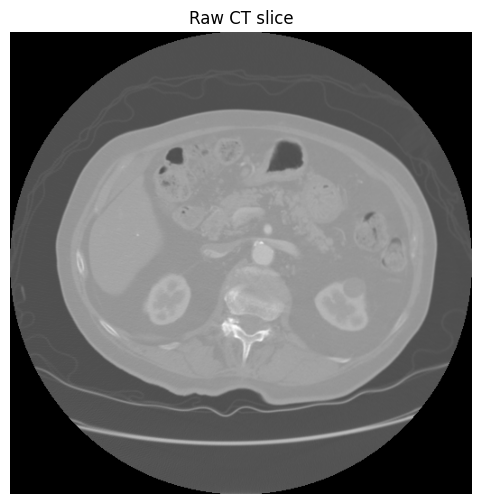

In [7]:
plt.figure(figsize=(6 , 6))
plt.imshow(image , cmap='gray')
plt.title('Raw CT slice')
plt.axis('off')
plt.show()

In [8]:
print("Minimum:", image.min())
print("Maximum:", image.max())
print("Mean:", image.mean())

Minimum: -1024
Maximum: 2271
Mean: 231.46599960327148


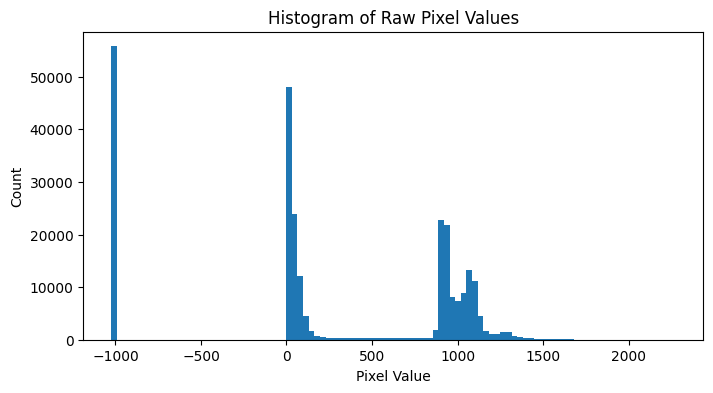

In [9]:
plt.figure(figsize=(8,4))

plt.hist(image.flatten(), bins=100)

plt.title("Histogram of Raw Pixel Values")

plt.xlabel("Pixel Value")

plt.ylabel("Count")

plt.show()

In [10]:
print("Rescale Slope:", ds.RescaleSlope)
print("Rescale Intercept:", ds.RescaleIntercept)

Rescale Slope: 1
Rescale Intercept: -1024


In [11]:
hu_image = image * ds.RescaleSlope + ds.RescaleIntercept

In [12]:
print("HU Min:", hu_image.min())
print("HU Max:", hu_image.max())

HU Min: -2048.0
HU Max: 1247.0


In [13]:
dicom_file= list(dicom_folder.glob('*.dcm'))
print(f'found {len(dicom_file)} slices')

found 133 slices


In [14]:
dicom_file.sort(
    key=lambda f: pydicom.dcmread(
        f,
        stop_before_pixels=True
    ).InstanceNumber
)

In [15]:
images = []
for file in dicom_file:
    ds = pydicom.dcmread(file)
    images.append(ds.pixel_array)

In [17]:
def show_slice(index):
    plt.figure(figsize=(6 ,6))
    plt.imshow(images[index] , cmap='gray')
    plt.title(f"Slice {index+1}/{len(images)}")
    plt.axis('off')
    plt.show()

interact(
    show_slice,
    index=IntSlider(
        min=0,
        max=len(images)-1,
        step=1,
        value=len(images)//2
    )
)

interactive(children=(IntSlider(value=66, description='index', max=132), Output()), _dom_classes=('widget-inte…

<function __main__.show_slice(index)>